# 01 - Inspeccion orientada a balanceo temporal

Este notebook realiza un EDA por subgrupos, ad-hoc y orientado a decisiones experimentales de balanceo para prediccion de glucosa.

Objetivo: caracterizar el desbalanceo real (global, por paciente, temporal y demografico) para seleccionar tecnicas de balanceo y estrategia de evaluacion.

## Glosario operativo y de auditoria (EDA temporal)

Este glosario fija el significado exacto de la terminologia usada en este notebook para que la lectura sea reproducible y auditable.

- **Episodio**: tramo consecutivo de mediciones de un mismo paciente con la misma clase clinica (`hypoglycemia`, `normoglycemia`, `hyperglycemia`).
- **Inicio de episodio**: primera fila donde cambia la clase respecto a la medicion anterior del mismo paciente (`class_label != prev_class`).
- **Paso**: una observacion temporal individual dentro de la serie de un paciente (no equivale necesariamente a minutos fijos).
- **Paso relativo (`rel_step`)**: posicion respecto al inicio del episodio. `0` es el cruce/arranque del episodio; negativos son contexto previo; positivos son evolucion posterior.
- **Ventana de pasos**: subconjunto contiguo de pasos alrededor de un punto de referencia. Ejemplo: `-24:+12` usa 24 pasos previos y 12 posteriores.
- **Lookback window**: numero de pasos previos usados para extraer contexto predictor (`w` en 8, 12, 24, 48).
- **Trazas alineadas a evento**: series de glucosa reindexadas por `rel_step` para comparar dinamica entre episodios de distinta longitud absoluta.
- **Submuestreo por clase**: limite de hasta 1000 inicios por clase para controlar coste computacional y evitar dominancia de la clase mayoritaria.
- **Varianza previa (`pre_var`)**: dispersion de glucosa dentro de la ventana previa al evento.
- **Pendiente previa (`pre_slope`)**: tendencia lineal en la ventana previa; negativa indica caida, positiva subida.
- **Autocorrelacion**: dependencia temporal de la serie con su propio pasado; alta autocorrelacion sugiere rafagas/no independencia i.i.d.
- **Ratio de desbalanceo**: cociente entre clase mayoritaria y minoritaria por paciente; se usa para cuantificar severidad del desbalance.
- **Separabilidad**: grado en que las clases se distinguen por sus estadisticos temporales (estimada con tamano de efecto de Cohen).

Criterio transversal de auditoria aplicado en todo el notebook:
- **Fuente de datos**: `Patient_info.csv` y `Glucose_measurements.parquet` (integrados por `Patient_ID` cuando aplica).
- **Regla de temporalidad**: toda operacion dependiente del tiempo se calcula tras ordenar por `Patient_ID` y `timestamp`.
- **Regla de trazabilidad**: cada figura se justifica con variables intermedias nombradas en codigo (`analysis_glucose`, `episodes`, `aligned_df`, `pre_features`, etc.).
- **Regla de integridad**: `Measurement` se convierte a `float` para evitar overflow y preservar decimales.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import random
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 200)

def find_project_root(start: Path) -> Path:
    """Find workspace root by locating data/T1DiabetesGranada."""
    for candidate in [start] + list(start.parents):
        if (candidate / 'data' / 'T1DiabetesGranada').exists():
            return candidate
    raise FileNotFoundError('No se encontro la carpeta data/T1DiabetesGranada desde el directorio actual.')

ROOT = find_project_root(Path.cwd())
DATA_DIR = ROOT / 'data' / 'T1DiabetesGranada'

print(f'ROOT detectado: {ROOT}')
print(f'DATA_DIR: {DATA_DIR}')

ROOT detectado: c:\Users\User\Desktop\TFM-Glucose-Prediction
DATA_DIR: c:\Users\User\Desktop\TFM-Glucose-Prediction\data\T1DiabetesGranada


In [3]:
# Carga de datos (patient_info CSV + glucose parquet)
patient_info = pd.read_csv(DATA_DIR / 'Patient_info.csv')
glucose = pd.read_parquet(DATA_DIR / 'Glucose_measurements_T1DiabetesGranada_FILTERED_2026-03-27.parquet')

# Estandarizacion de clave de join y columnas principales
if 'Patient_Id' in patient_info.columns and 'Patient_ID' not in patient_info.columns:
    patient_info.rename(columns={'Patient_Id': 'Patient_ID'}, inplace=True)

rename_map = {
    'patient_id': 'Patient_ID',
    'measurement_date': 'Measurement_date',
    'measurement_time': 'Measurement_time',
    'measurement': 'Measurement'
}
glucose.rename(columns={k: v for k, v in rename_map.items() if k in glucose.columns}, inplace=True)

if 'Patient_Id' in glucose.columns and 'Patient_ID' not in glucose.columns:
    glucose.rename(columns={'Patient_Id': 'Patient_ID'}, inplace=True)

# Normalizar tipo de Patient_ID para evitar errores de merge
if 'Patient_ID' not in patient_info.columns or 'Patient_ID' not in glucose.columns:
    raise ValueError('Falta columna Patient_ID en patient_info o glucose.')
patient_info['Patient_ID'] = patient_info['Patient_ID'].astype(str)
glucose['Patient_ID'] = glucose['Patient_ID'].astype(str)

# Parseo temporal
if {'Measurement_date', 'Measurement_time'}.issubset(glucose.columns):
    glucose['timestamp'] = pd.to_datetime(
        glucose['Measurement_date'].astype(str) + ' ' + glucose['Measurement_time'].astype(str),
        errors='coerce'
    )
elif 'Measurement_date' in glucose.columns:
    glucose['timestamp'] = pd.to_datetime(glucose['Measurement_date'], errors='coerce')
elif '15min' in glucose.columns:
    glucose['timestamp'] = pd.to_datetime(glucose['15min'], errors='coerce')
elif '5min' in glucose.columns:
    glucose['timestamp'] = pd.to_datetime(glucose['5min'], errors='coerce')
else:
    raise ValueError('No se encontraron columnas de fecha/hora en Glucose_measurements.parquet')

# Glucosa numerica y etiquetas clinicas (usar float para evitar overflow y mantener decimales)
glucose['Measurement'] = pd.to_numeric(glucose['Measurement'], errors='coerce').astype(float)

def glucose_class(value: float) -> str:
    if pd.isna(value):
        return 'missing'
    if value < 70:
        return 'hypoglycemia'
    if value <= 180:
        return 'normoglycemia'
    return 'hyperglycemia'

glucose['class_label'] = glucose['Measurement'].apply(glucose_class)

# Join por paciente a nivel resumen (evita explosion many-to-many)
glucose_agg = glucose.groupby('Patient_ID', as_index=False).agg(
    glucose_records=('Measurement', 'size'),
    glucose_min=('Measurement', 'min'),
    glucose_max=('Measurement', 'max'),
    glucose_mean=('Measurement', 'mean'),
    first_glucose_ts=('timestamp', 'min'),
    last_glucose_ts=('timestamp', 'max')
)

patient_master = patient_info.merge(glucose_agg, on='Patient_ID', how='left')

print('Shapes cargados:')
print('patient_info:', patient_info.shape)
print('glucose:', glucose.shape)
print('patient_master (join por Patient_ID):', patient_master.shape)

display(patient_master.head(3))

Shapes cargados:
patient_info: (736, 11)
glucose: (30477434, 8)
patient_master (join por Patient_ID): (736, 17)


,Patient_ID,Sex,Birth_year,Initial_measurement_date,Final_measurement_date,Number_of_days_with_measures,Number_of_measurements,Initial_biochemical_parameters_date,Final_biochemical_parameters_date,Number_of_biochemical_parameters,Number_of_diagnostics,glucose_records,glucose_min,glucose_max,glucose_mean,first_glucose_ts,last_glucose_ts
0,LIB193263,M,1965,2020-06-09,2022-03-19,648,60097,NaN,NaN,NaN,1.0,62222.0,40.0,492.0,177.817248,2020-06-09 19:08:00,2022-03-19 07:32:00
1,LIB193264,F,1975,2020-06-10,2022-03-19,326,26786,NaN,NaN,NaN,3.0,62157.0,40.0,372.0,149.991675,2020-06-10 00:54:00,2022-03-19 11:56:00
2,LIB193265,F,1980,2019-01-27,2022-03-19,581,46575,2018-09-05,2021-10-01,120.0,NaN,110176.0,40.0,500.0,133.811298,2019-01-27 10:52:00,2022-03-19 22:04:00


In [4]:
# Documentacion de schema completo (tipos, nulos, rangos)
def summarize_schema(df: pd.DataFrame, name: str) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        s = df[col]
        dtype = str(s.dtype)
        nulls = int(s.isna().sum())
        null_pct = float(s.isna().mean() * 100)

        min_val, max_val = None, None
        if pd.api.types.is_numeric_dtype(s):
            min_val = s.min(skipna=True)
            max_val = s.max(skipna=True)
        elif pd.api.types.is_datetime64_any_dtype(s):
            min_val = s.min(skipna=True)
            max_val = s.max(skipna=True)
        else:
            non_null = s.dropna().astype(str)
            if len(non_null) > 0:
                min_val = non_null.min()
                max_val = non_null.max()

        rows.append({
            'dataset': name,
            'column': col,
            'dtype': dtype,
            'nulls': nulls,
            'null_pct': round(null_pct, 2),
            'min': min_val,
            'max': max_val,
            'n_unique': int(s.nunique(dropna=True))
        })
    return pd.DataFrame(rows)

schema_report = pd.concat([
    summarize_schema(patient_info, 'patient_info'),
    summarize_schema(glucose, 'glucose_measurements')
], ignore_index=True)

print('Schema completo por archivo:')
display(schema_report)

print('\nResumen de nulos por dataset:')
display(schema_report.groupby('dataset', as_index=False)['null_pct'].mean().rename(columns={'null_pct': 'avg_null_pct'}))

print('\nDefinicion de clases clinicas aplicada:')
print('hypoglycemia: glucosa < 70 mg/dL')
print('normoglycemia: 70-180 mg/dL')
print('hyperglycemia: > 180 mg/dL')

Schema completo por archivo:


,dataset,column,dtype,nulls,null_pct,min,max,n_unique
0,patient_info,Patient_ID,object,0,0.00,LIB193263,LIB194166,736
1,patient_info,Sex,object,0,0.00,F,M,2
2,patient_info,Birth_year,int64,0,0.00,1936,2005,69
3,patient_info,Initial_measurement_date,object,0,0.00,2018-01-06,2022-02-24,329
4,patient_info,Final_measurement_date,object,0,0.00,2019-01-20,2022-03-21,173
5,patient_info,Number_of_days_with_measures,int64,0,0.00,8,1463,468
6,patient_info,Number_of_measurements,int64,0,0.00,400,137292,729
7,patient_info,Initial_biochemical_parameters_date,object,13,1.77,2018-01-01,2021-08-23,271
8,patient_info,Final_biochemical_parameters_date,object,13,1.77,2018-11-21,2022-03-21,238
9,patient_info,Number_of_biochemical_parameters,float64,13,1.77,4.0,846.0,234



Resumen de nulos por dataset:


,dataset,avg_null_pct
0,glucose_measurements,26.173750
1,patient_info,3.261818



Definicion de clases clinicas aplicada:
hypoglycemia: glucosa < 70 mg/dL
normoglycemia: 70-180 mg/dL
hyperglycemia: > 180 mg/dL


## Bloque 1 - Caracterizacion del desbalanceo

Preguntas:
- Cual es la distribucion de clases global y por paciente?
- Hay pacientes con desbalanceo extremo (ratio > 1:20)?
- Las clases minoritarias se concentran en pocos pacientes?

### Guia de lectura y auditoria del Bloque 1 (desbalanceo global y por paciente)

**Que muestran las graficas y tablas:**
- Distribucion global de clases (barra): proporciones agregadas de hipo/normo/hiper.
- Variabilidad interpaciente del desbalance (boxplot log): dispersion del ratio maximo por paciente.
- Tabla por paciente: recuentos absolutos, porcentajes y severidad del desbalance.

**Como se construyen (pipeline):**
1. Se filtra `glucose` a clases clinicas validas (`class_order`).
2. Se agrega por paciente y clase para obtener conteos.
3. Se calculan porcentajes por paciente y ratios `normo/minoritaria`.
4. Se clasifica severidad (`leve`, `moderado`, `severo`, `extremo`).

**Datos y variables trazables:**
- Fuente principal: `glucose` (`Measurement`, `class_label`, `Patient_ID`).
- Tablas intermedias: `global_dist`, `patient_class_counts`, `dist_by_patient_table`.
- Indicadores de concentracion: `top5_hypo_share`, `top5_hyper_share`.

**Justificacion analitica:**
- Este bloque valida si el problema esta desbalanceado en promedio y si ese desbalance cambia mucho entre pacientes.
- La escala log del boxplot evita ocultar extremos clinicamente relevantes.

**Control de calidad / auditoria:**
- Verificar que `class_order` este completo y sin clases espurias.
- Confirmar que los porcentajes por paciente suman ~100%.
- Revisar presencia de `inf` en ratios cuando falta una minoritaria (caso esperado, no error).

### Tabla - Distribucion de clases por paciente (absoluta y porcentaje)

class_label,Patient_ID,hypoglycemia,normoglycemia,hyperglycemia,pct_hypoglycemia,pct_normoglycemia,pct_hyperglycemia,imbalance_ratio_max,imbalance_severity
591,LIB194101,0,2330,5659,0.000000,29.165102,70.834898,inf,extremo_sin_minoritaria
373,LIB193812,1013,13143,0,7.155976,92.844024,0.000000,inf,extremo_sin_minoritaria
396,LIB193839,0,3459,4201,0.000000,45.156658,54.843342,inf,extremo_sin_minoritaria
542,LIB194037,3,4248,5162,0.031871,45.129077,54.839052,1416.000000,severo_>1:20
223,LIB193599,1,1358,3481,0.020661,28.057851,71.921488,1358.000000,severo_>1:20
...,...,...,...,...,...,...,...,...,...
548,LIB194044,10338,30351,9867,20.448611,60.034417,19.516971,3.076011,leve_<=1:5
414,LIB193861,3300,10061,9852,14.216172,43.342093,42.441735,3.048788,leve_<=1:5
520,LIB194010,1468,4291,2831,17.089639,49.953434,32.956927,2.923025,leve_<=1:5
626,LIB194144,1212,3342,5673,11.850983,32.678205,55.470813,2.757426,leve_<=1:5


### Pregunta: Cual es la distribucion de clases global?

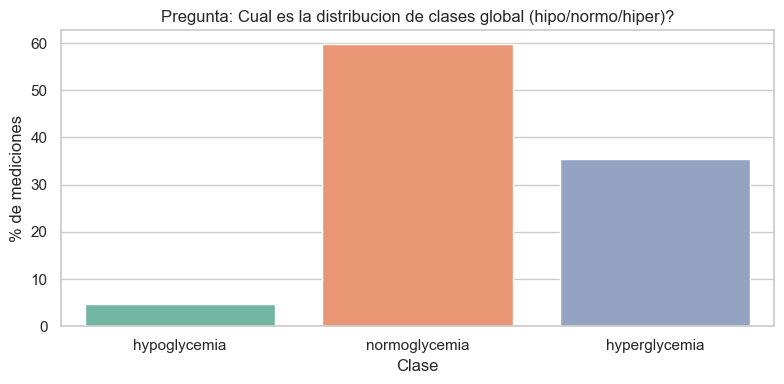

### Pregunta: Hay alta variabilidad del ratio de desbalanceo entre pacientes?

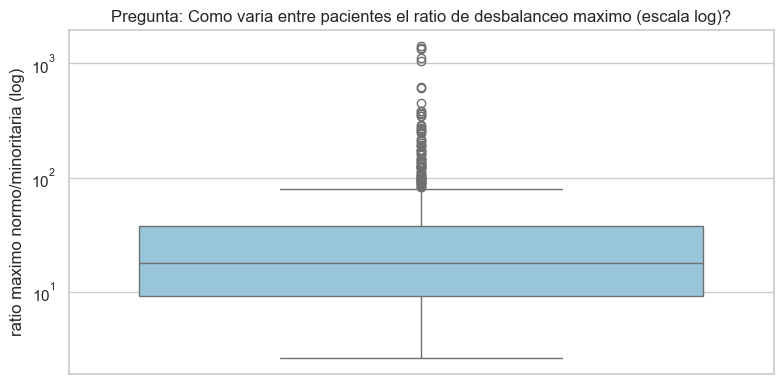

Top 5 pacientes concentran 6.82% de episodios de hypoglycemia.
Top 5 pacientes concentran 4.05% de episodios de hyperglycemia.

Subgrupos por severidad del desbalanceo (pacientes):


,severidad,n_patients
0,moderado_1:5_a_1:20,312
1,severo_>1:20,296
2,leve_<=1:5,32
3,extremo_sin_minoritaria,3


In [5]:
# Bloque 1: distribucion global y por paciente
class_order = ['hypoglycemia', 'normoglycemia', 'hyperglycemia']

global_dist = (
    glucose.loc[glucose['class_label'].isin(class_order), 'class_label']
    .value_counts()
    .reindex(class_order, fill_value=0)
    .rename_axis('class_label')
    .reset_index(name='count')
)
global_dist['pct'] = 100 * global_dist['count'] / global_dist['count'].sum()

# Distribucion por paciente
patient_class_counts = (
    glucose[glucose['class_label'].isin(class_order)]
    .groupby(['Patient_ID', 'class_label'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=class_order, fill_value=0)
    .reset_index()
)

patient_class_counts['total'] = patient_class_counts[class_order].sum(axis=1)
for c in class_order:
    patient_class_counts[f'pct_{c}'] = 100 * patient_class_counts[c] / patient_class_counts['total']

# Ratios normo/minoritaria para detectar severidad
patient_class_counts['ratio_normo_hypo'] = np.where(
    patient_class_counts['hypoglycemia'] > 0,
    patient_class_counts['normoglycemia'] / patient_class_counts['hypoglycemia'],
    np.inf
)
patient_class_counts['ratio_normo_hyper'] = np.where(
    patient_class_counts['hyperglycemia'] > 0,
    patient_class_counts['normoglycemia'] / patient_class_counts['hyperglycemia'],
    np.inf
)
patient_class_counts['imbalance_ratio_max'] = patient_class_counts[['ratio_normo_hypo', 'ratio_normo_hyper']].max(axis=1)

patient_class_counts['imbalance_severity'] = np.select(
    [
        np.isinf(patient_class_counts['imbalance_ratio_max']),
        patient_class_counts['imbalance_ratio_max'] > 20,
        patient_class_counts['imbalance_ratio_max'] > 5
    ],
    ['extremo_sin_minoritaria', 'severo_>1:20', 'moderado_1:5_a_1:20'],
    default='leve_<=1:5'
)

# Output requerido: tabla absoluta + porcentaje por paciente
dist_by_patient_table = patient_class_counts[[
    'Patient_ID',
    'hypoglycemia', 'normoglycemia', 'hyperglycemia',
    'pct_hypoglycemia', 'pct_normoglycemia', 'pct_hyperglycemia',
    'imbalance_ratio_max', 'imbalance_severity'
]].sort_values('imbalance_ratio_max', ascending=False)

display(Markdown('### Tabla - Distribucion de clases por paciente (absoluta y porcentaje)'))
display(dist_by_patient_table)

display(Markdown('### Pregunta: Cual es la distribucion de clases global?'))
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=global_dist, x='class_label', y='pct', order=class_order, palette='Set2', ax=ax)
ax.set_title('Pregunta: Cual es la distribucion de clases global (hipo/normo/hiper)?')
ax.set_xlabel('Clase')
ax.set_ylabel('% de mediciones')
plt.tight_layout()
plt.show()

display(Markdown('### Pregunta: Hay alta variabilidad del ratio de desbalanceo entre pacientes?'))
ratio_plot_df = patient_class_counts.replace([np.inf, -np.inf], np.nan).dropna(subset=['imbalance_ratio_max'])
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=ratio_plot_df, y='imbalance_ratio_max', color='#8ecae6', ax=ax)
ax.set_yscale('log')
ax.set_title('Pregunta: Como varia entre pacientes el ratio de desbalanceo maximo (escala log)?')
ax.set_ylabel('ratio maximo normo/minoritaria (log)')
plt.tight_layout()
plt.show()

# Concentracion de minoritarias en pocos pacientes
hypo_concentration = (
    patient_class_counts[['Patient_ID', 'hypoglycemia']]
    .sort_values('hypoglycemia', ascending=False)
    .reset_index(drop=True)
)
hyper_concentration = (
    patient_class_counts[['Patient_ID', 'hyperglycemia']]
    .sort_values('hyperglycemia', ascending=False)
    .reset_index(drop=True)
)

def top_share(df_counts: pd.DataFrame, col: str, k: int = 5) -> float:
    total = df_counts[col].sum()
    if total == 0:
        return np.nan
    return 100 * df_counts[col].head(k).sum() / total

top5_hypo_share = top_share(hypo_concentration, 'hypoglycemia', 5)
top5_hyper_share = top_share(hyper_concentration, 'hyperglycemia', 5)

print('Top 5 pacientes concentran %.2f%% de episodios de hypoglycemia.' % top5_hypo_share)
print('Top 5 pacientes concentran %.2f%% de episodios de hyperglycemia.' % top5_hyper_share)
print('\nSubgrupos por severidad del desbalanceo (pacientes):')
display(patient_class_counts['imbalance_severity'].value_counts().rename_axis('severidad').reset_index(name='n_patients'))

In [6]:
# Implicacion para experimentos - Bloque 1
n_extreme = int((patient_class_counts['imbalance_ratio_max'] > 20).sum())
share_extreme = 100 * n_extreme / patient_class_counts.shape[0]

imp_b1 = f"""
**Implicacion para los experimentos:**
Se observa heterogeneidad de desbalanceo entre pacientes; {n_extreme} de {patient_class_counts.shape[0]} pacientes ({share_extreme:.1f}%) presentan ratio maximo > 1:20 o ausencia de alguna minoritaria.
Esto sugiere simular ratios realistas por estratos de severidad en lugar de un unico ratio global y evaluar robustez por subgrupos de pacientes extremos.
"""
display(Markdown(imp_b1))


**Implicacion para los experimentos:**
Se observa heterogeneidad de desbalanceo entre pacientes; 299 de 643 pacientes (46.5%) presentan ratio maximo > 1:20 o ausencia de alguna minoritaria.
Esto sugiere simular ratios realistas por estratos de severidad en lugar de un unico ratio global y evaluar robustez por subgrupos de pacientes extremos.


## Bloque 2 - Estructura temporal del desbalanceo

Preguntas:
- Las clases minoritarias aparecen en rafagas o aleatoriamente?
- Hay patrones por hora del dia o dia de semana?
- Cuanto duran los episodios consecutivos por clase?

### Guia de lectura y auditoria del Bloque 2 (estructura temporal)

**Que muestran las graficas:**
- Autocorrelacion por clase: si los eventos minoritarios aparecen en rafagas o de forma casi aleatoria.
- Longitud de episodios por clase (boxplot log): cuantos pasos consecutivos dura cada estado clinico.
- Heatmaps por subgrupo: distribucion hora x clase para detectar ritmos diarios diferenciales.

**Como se construyen (pipeline):**
1. Se crea `analysis_glucose` filtrando clases validas y eliminando nulos temporales.
2. Se ordena por `Patient_ID` y `timestamp` para respetar causalidad temporal.
3. Se calculan conteos horarios y autocorrelaciones por `lag`.
4. Se segmentan episodios consecutivos con cambios de paciente o de clase (`change_group`).
5. Se generan tablas hora x clase por subgrupo demografico cuando hay informacion disponible.

**Datos y variables trazables:**
- Fuente principal: `glucose` + metadatos de `patient_info` (si existen `Sex`, `Birth_year`).
- Objetos clave: `analysis_glucose`, `hourly_counts`, `autocorr_df`, `episodes`, `subgroup_col`.

**Justificacion analitica:**
- Si existe dependencia temporal, balancear muestras aisladas puede romper la estructura real de la señal.
- La longitud de episodios informa el tamano minimo util de ventana para modelado secuencial.

**Control de calidad / auditoria:**
- Comprobar orden cronologico real en `analysis_glucose`.
- Revisar que `episodes['length'] >= 1` siempre.
- Interpretar heatmaps solo cuando `n` por subgrupo sea suficiente (evitar sobreinterpretacion de grupos pequenos).

### Pregunta: Las clases minoritarias aparecen en rafagas temporales?

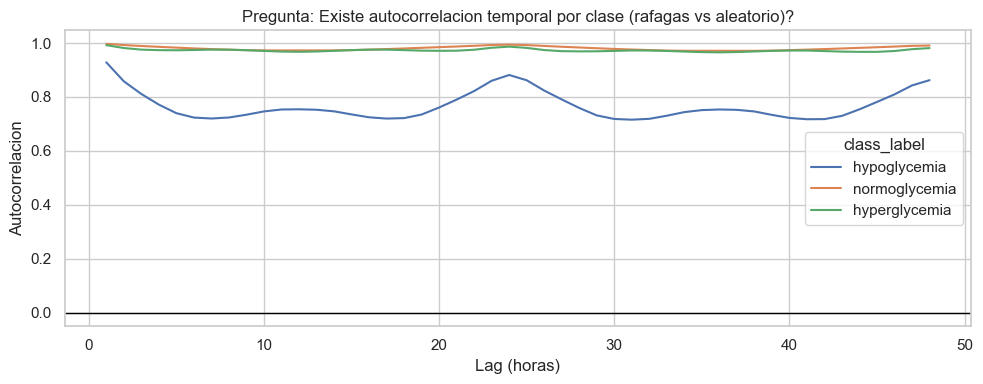

### Pregunta: Cuanto duran los episodios consecutivos por clase?

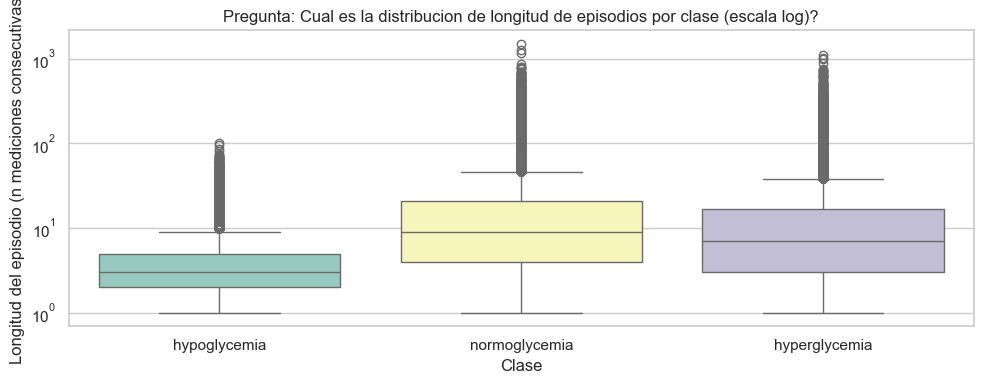

,count,mean,std,min,25%,50%,75%,max
class_label,,,,,,,,
hypoglycemia,236381.0,4.489921,4.930047,1.0,2.0,3.0,5.0,100.0
normoglycemia,836914.0,15.860775,20.340728,1.0,4.0,9.0,21.0,1501.0
hyperglycemia,606550.0,13.020900,17.800853,1.0,3.0,7.0,17.0,1115.0


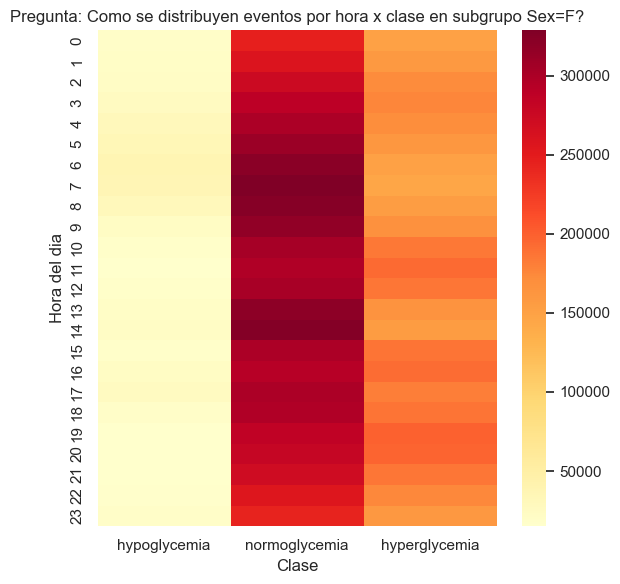

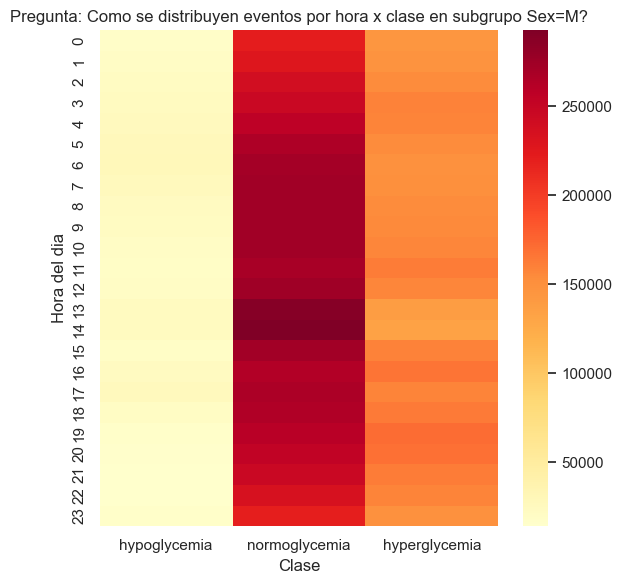

In [7]:
# Bloque 2: estructura temporal

# Preparacion temporal
analysis_glucose = glucose[glucose['class_label'].isin(class_order)].copy()
analysis_glucose = analysis_glucose.dropna(subset=['timestamp', 'Measurement'])
analysis_glucose = analysis_glucose.sort_values(['Patient_ID', 'timestamp']).reset_index(drop=True)

analysis_glucose['hour'] = analysis_glucose['timestamp'].dt.hour
analysis_glucose['dayofweek'] = analysis_glucose['timestamp'].dt.day_name()

# Añadir subgrupos demograficos disponibles
analysis_glucose = analysis_glucose.merge(patient_info[['Patient_ID', 'Sex', 'Birth_year']] if {'Sex', 'Birth_year'}.issubset(patient_info.columns)
                                        else patient_info[['Patient_ID']],
                                        on='Patient_ID', how='left')

if 'Birth_year' in analysis_glucose.columns:
    ref_year = int(analysis_glucose['timestamp'].dt.year.max())
    analysis_glucose['Age'] = ref_year - pd.to_numeric(analysis_glucose['Birth_year'], errors='coerce')
    analysis_glucose['age_group'] = pd.cut(
        analysis_glucose['Age'],
        bins=[0, 18, 30, 45, 60, 120],
        labels=['<=18', '19-30', '31-45', '46-60', '>60'],
        include_lowest=True
    )

# 2.1 Autocorrelacion por clase (sobre conteos horarios)
hourly_counts = (
    analysis_glucose
    .set_index('timestamp')
    .groupby('class_label')
    .resample('1H')['Measurement']
    .count()
    .reset_index()
    .pivot(index='timestamp', columns='class_label', values='Measurement')
    .fillna(0)
    .reindex(columns=class_order, fill_value=0)
)

lags = range(1, 49)
autocorr_rows = []
for c in class_order:
    s = hourly_counts[c]
    for lag in lags:
        autocorr_rows.append({'class_label': c, 'lag_hours': lag, 'autocorr': s.autocorr(lag=lag)})
autocorr_df = pd.DataFrame(autocorr_rows)

display(Markdown('### Pregunta: Las clases minoritarias aparecen en rafagas temporales?'))
fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=autocorr_df, x='lag_hours', y='autocorr', hue='class_label', hue_order=class_order, ax=ax)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Pregunta: Existe autocorrelacion temporal por clase (rafagas vs aleatorio)?')
ax.set_xlabel('Lag (horas)')
ax.set_ylabel('Autocorrelacion')
plt.tight_layout()
plt.show()

# 2.2 Longitud de episodios consecutivos
change_group = (
    (analysis_glucose['Patient_ID'] != analysis_glucose['Patient_ID'].shift(1)) |
    (analysis_glucose['class_label'] != analysis_glucose['class_label'].shift(1))
).cumsum()

episodes = (
    analysis_glucose
    .groupby(change_group)
    .agg(
        Patient_ID=('Patient_ID', 'first'),
        class_label=('class_label', 'first'),
        start_ts=('timestamp', 'first'),
        end_ts=('timestamp', 'last'),
        length=('class_label', 'size')
    )
    .reset_index(drop=True)
)

display(Markdown('### Pregunta: Cuanto duran los episodios consecutivos por clase?'))
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=episodes, x='class_label', y='length', order=class_order, ax=ax, palette='Set3')
ax.set_yscale('log')
ax.set_title('Pregunta: Cual es la distribucion de longitud de episodios por clase (escala log)?')
ax.set_xlabel('Clase')
ax.set_ylabel('Longitud del episodio (n mediciones consecutivas)')
plt.tight_layout()
plt.show()

display(episodes.groupby('class_label')['length'].describe().reindex(class_order))

# 2.3 Heatmap hora x clase por subgrupo demografico
if 'Sex' in analysis_glucose.columns and analysis_glucose['Sex'].notna().any():
    subgroup_col = 'Sex'
elif 'age_group' in analysis_glucose.columns and analysis_glucose['age_group'].notna().any():
    subgroup_col = 'age_group'
else:
    subgroup_col = None

if subgroup_col is not None:
    subgroup_values = [v for v in analysis_glucose[subgroup_col].dropna().astype(str).unique()]
    subgroup_values = sorted(subgroup_values)[:4]

    for sv in subgroup_values:
        subset = analysis_glucose[analysis_glucose[subgroup_col].astype(str) == sv]
        heat = (
            subset.groupby(['hour', 'class_label'])
            .size()
            .unstack(fill_value=0)
            .reindex(columns=class_order, fill_value=0)
        )

        fig, ax = plt.subplots(figsize=(6, 6))
        sns.heatmap(heat, cmap='YlOrRd', annot=False, cbar=True, ax=ax)
        ax.set_title(f'Pregunta: Como se distribuyen eventos por hora x clase en subgrupo {subgroup_col}={sv}?')
        ax.set_xlabel('Clase')
        ax.set_ylabel('Hora del dia')
        plt.tight_layout()
        plt.show()
else:
    print('No hay columna demografica disponible para heatmap por subgrupo.')

In [8]:
# Implicacion para experimentos - Bloque 2
minority_ac = autocorr_df[autocorr_df['class_label'].isin(['hypoglycemia', 'hyperglycemia'])]
mean_minor_ac = minority_ac.groupby('class_label')['autocorr'].mean().to_dict()
median_epi = episodes.groupby('class_label')['length'].median().to_dict()

imp_b2 = f"""
**Implicacion para los experimentos:**
Las clases minoritarias muestran autocorrelacion media no nula (hypo={mean_minor_ac.get('hypoglycemia', np.nan):.3f}, hyper={mean_minor_ac.get('hyperglycemia', np.nan):.3f}) y episodios consecutivos con mediana de longitud > 1 (hypo={median_epi.get('hypoglycemia', np.nan):.1f}, hyper={median_epi.get('hyperglycemia', np.nan):.1f}).
Esto respalda priorizar tecnicas de balanceo conscientes del contexto temporal (window-level balancing o variantes temporales de oversampling) en lugar de asumir independencia i.i.d.
"""
display(Markdown(imp_b2))


**Implicacion para los experimentos:**
Las clases minoritarias muestran autocorrelacion media no nula (hypo=0.766, hyper=0.973) y episodios consecutivos con mediana de longitud > 1 (hypo=3.0, hyper=7.0).
Esto respalda priorizar tecnicas de balanceo conscientes del contexto temporal (window-level balancing o variantes temporales de oversampling) en lugar de asumir independencia i.i.d.


## Bloque 3 - Heterogeneidad entre subgrupos demograficos

Preguntas:
- El desbalanceo varia por tipo de diabetes, edad, sexo, IMC?
- Hay subgrupos sin hipoglucemia (o casi sin eventos)?

### Guia de lectura y auditoria del Bloque 3 (heterogeneidad demografica)

**Que muestran tablas y graficas:**
- Tabla cruzada por variable demografica: nivel de desbalance y ausencia de eventos por subgrupo.
- Heatmaps y barras de cola extrema: posibles bolsillos de riesgo oculto.
- Regresiones Edad/IMC vs desbalance: gradientes continuos que no se ven en promedios globales.

**Como se construyen (pipeline):**
1. Se integra desbalance por paciente (`patient_class_counts`) con `patient_info`.
2. Se derivan grupos de edad y, si existe, categorias de IMC.
3. Se evalua capacidad explicativa por variable (eta2 para categoricas, Spearman para numericas).
4. Se identifican subgrupos con ausencia de hipo y concentracion de casos extremos (top decil).

**Datos y variables trazables:**
- Tablas base: `patient_level`, `imbalance_by_demo`, `predictor_scores_df`.
- Alertas clinicas: `rare_hypo_table`, `extreme_table`, `clinical_alerts`.

**Justificacion analitica:**
- Evita conclusiones sesgadas por promedio global.
- Fundamenta una evaluacion estratificada clinicamente plausible.

**Control de calidad / auditoria:**
- Revisar tamano muestral por subgrupo (`n_patients`) antes de interpretar.
- Verificar manejo de nulos en variables demograficas.
- Tratar inferencias como exploratorias cuando los subgrupos son muy pequenos.

In [9]:
# Bloque 3: heterogeneidad demografica

# Dataset por paciente para modelar nivel de desbalanceo
patient_level = patient_class_counts.merge(patient_info, on='Patient_ID', how='left')
patient_level['imbalance_ratio_clean'] = patient_level['imbalance_ratio_max'].replace([np.inf, -np.inf], np.nan)

# Derivadas demograficas robustas
if 'Birth_year' in patient_level.columns:
    patient_level['Age'] = pd.Timestamp.today().year - pd.to_numeric(patient_level['Birth_year'], errors='coerce')
    patient_level['age_group'] = pd.cut(
        patient_level['Age'],
        bins=[0, 18, 30, 45, 60, 120],
        labels=['<=18', '19-30', '31-45', '46-60', '>60'],
        include_lowest=True
    )

# Buscar columna de tipo de diabetes y de IMC de forma flexible
type_candidates = ['Diabetes_type', 'Type_of_diabetes', 'DiabetesType', 'Type_Diabetes', 'DM_type']
bmi_candidates = ['BMI', 'Imc', 'Body_Mass_Index', 'BodyMassIndex']

diabetes_type_col = next((c for c in type_candidates if c in patient_level.columns), None)
bmi_col = next((c for c in bmi_candidates if c in patient_level.columns), None)
if bmi_col is not None:
    patient_level['BMI_numeric'] = pd.to_numeric(patient_level[bmi_col], errors='coerce')
    patient_level['BMI_group'] = pd.cut(
        patient_level['BMI_numeric'],
        bins=[0, 18.5, 25, 30, 60],
        labels=['underweight', 'normal', 'overweight', 'obesity'],
        include_lowest=True
    )

candidate_group_vars = [diabetes_type_col, 'Sex', 'age_group', 'BMI_group']
candidate_group_vars = [c for c in candidate_group_vars if c is not None and c in patient_level.columns]

# Tabla cruzada: ratio de desbalanceo por variable demografica
cross_tables = []
for var in candidate_group_vars:
    tmp = (
        patient_level.groupby(var, dropna=False)
        .agg(
            n_patients=('Patient_ID', 'nunique'),
            median_ratio=('imbalance_ratio_clean', 'median'),
            mean_ratio=('imbalance_ratio_clean', 'mean'),
            hypo_absent_pct=('hypoglycemia', lambda s: 100 * (s == 0).mean()),
            hyper_absent_pct=('hyperglycemia', lambda s: 100 * (s == 0).mean())
        )
        .reset_index()
    )
    tmp.insert(0, 'demographic_variable', var)
    cross_tables.append(tmp)

if len(cross_tables) > 0:
    imbalance_by_demo = pd.concat(cross_tables, ignore_index=True)
    display(Markdown('### Tabla cruzada - Ratio de desbalanceo por variable demografica'))
    display(imbalance_by_demo)
else:
    imbalance_by_demo = pd.DataFrame()
    print('No se encontraron variables demograficas suficientes para tabla cruzada.')

# Variables demograficas mas predictoras del nivel de desbalanceo
# Score para categoricas: fraccion de varianza explicada por grupos (eta2 simplificado)
# Score para numericas: |correlacion Spearman|
def eta2_for_category(df: pd.DataFrame, cat_col: str, y_col: str) -> float:
    d = df[[cat_col, y_col]].dropna().copy()
    if d.empty or d[cat_col].nunique() < 2:
        return np.nan
    y = d[y_col]
    grand_mean = y.mean()
    ss_total = ((y - grand_mean) ** 2).sum()
    group_means = d.groupby(cat_col)[y_col].mean()
    group_sizes = d.groupby(cat_col)[y_col].size()
    ss_between = ((group_means - grand_mean) ** 2 * group_sizes).sum()
    return float(ss_between / ss_total) if ss_total > 0 else np.nan

predictor_scores = []
target = 'imbalance_ratio_clean'

for var in candidate_group_vars:
    predictor_scores.append({
        'variable': var,
        'type': 'categorical',
        'predictive_score': eta2_for_category(patient_level, var, target)
    })

for num_var in ['Age', 'BMI_numeric']:
    if num_var in patient_level.columns:
        corr = patient_level[[num_var, target]].corr(method='spearman').iloc[0, 1]
        predictor_scores.append({
            'variable': num_var,
            'type': 'numeric',
            'predictive_score': abs(float(corr)) if pd.notna(corr) else np.nan
        })

predictor_scores_df = pd.DataFrame(predictor_scores).sort_values('predictive_score', ascending=False)
display(Markdown('### Variables demograficas mas predictoras del nivel de desbalanceo'))
display(predictor_scores_df)

# Subgrupos con hipoglucemia casi inexistente
rare_hypo_groups = []
for var in candidate_group_vars:
    tmp = patient_level.groupby(var)['hypoglycemia'].apply(lambda s: 100 * (s == 0).mean()).reset_index(name='pct_patients_without_hypo')
    tmp['variable'] = var
    rare_hypo_groups.append(tmp)

if rare_hypo_groups:
    rare_hypo_table = pd.concat(rare_hypo_groups, ignore_index=True)
    rare_hypo_table = rare_hypo_table.sort_values('pct_patients_without_hypo', ascending=False)
    display(Markdown('### Subgrupos donde hipoglucemia es casi inexistente'))
    display(rare_hypo_table.head(15))
else:
    rare_hypo_table = pd.DataFrame()

### Tabla cruzada - Ratio de desbalanceo por variable demografica

,demographic_variable,Sex,n_patients,median_ratio,mean_ratio,hypo_absent_pct,hyper_absent_pct,age_group
0,Sex,F,334,20.877701,55.177599,0.299401,0.299401,NaN
1,Sex,M,309,14.425728,41.669161,0.323625,0.000000,NaN
2,age_group,NaN,0,NaN,NaN,NaN,NaN,<=18
3,age_group,NaN,98,13.409976,22.653730,0.000000,0.000000,19-30
4,age_group,NaN,181,14.463217,35.966723,0.000000,0.552486,31-45
5,age_group,NaN,205,17.098176,51.462494,0.487805,0.000000,46-60
6,age_group,NaN,159,22.537466,75.700252,0.628931,0.000000,>60


### Variables demograficas mas predictoras del nivel de desbalanceo

,variable,type,predictive_score
2,Age,numeric,0.197900
1,age_group,categorical,0.020785
0,Sex,categorical,0.002853


### Subgrupos donde hipoglucemia es casi inexistente

,Sex,pct_patients_without_hypo,variable,age_group
6,NaN,0.628931,age_group,>60
5,NaN,0.487805,age_group,46-60
1,M,0.323625,Sex,NaN
0,F,0.299401,Sex,NaN
4,NaN,0.000000,age_group,31-45
3,NaN,0.000000,age_group,19-30
2,NaN,NaN,age_group,<=18


### Preguntas clinicas avanzadas para no perder senales ocultas

- Se esta ocultando un subgrupo pequeno pero de muy alto riesgo en el promedio global?

- Hay interacciones edad x sexo donde el riesgo cambia mucho aunque por separado no parezca?

- Estamos confundiendo ausencia real de hipoglucemia con infra-deteccion en ciertos perfiles?

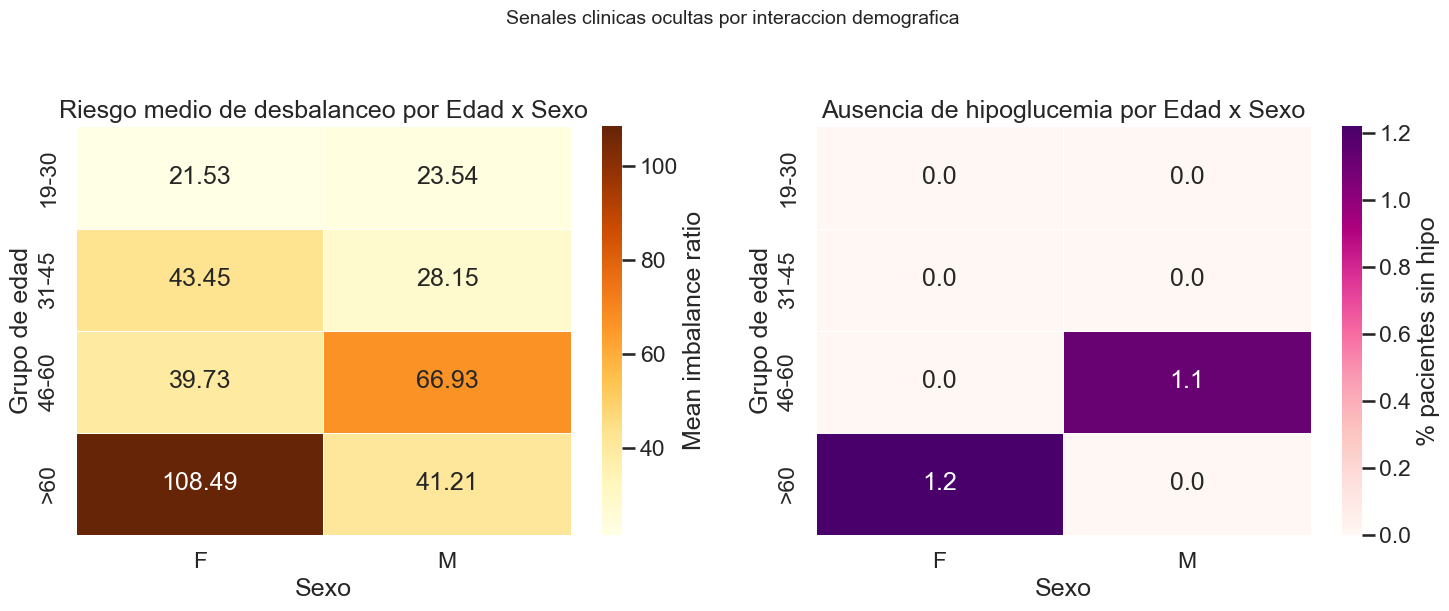

### Subgrupos con cola de riesgo extremo (top 10% de desbalanceo)

,subgroup_value,n_patients,extreme_pct,median_ratio,variable
6,>60,159,13.836478,22.537466,age_group
0,F,334,11.377246,20.877701,Sex
5,46-60,205,10.731707,17.098176,age_group
4,31-45,181,8.839779,14.463217,age_group
1,M,309,8.414239,14.425728,Sex
3,19-30,98,4.081633,13.409976,age_group


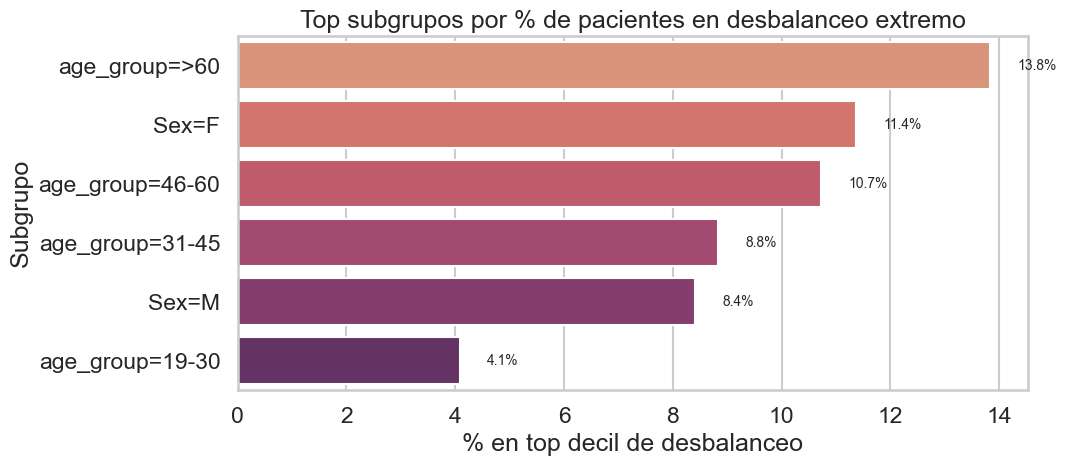

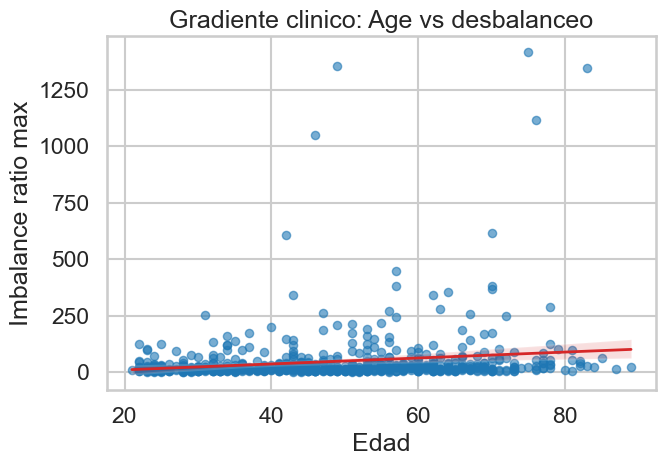

### Lectura clinica sugerida

- Gradiente relevante en Edad x Sexo para ratio de desbalanceo (delta=86.97).

- Existe un subgrupo con concentracion de casos extremos: age_group=>60 (13.8% en top decil).

In [10]:
# Bloque 3 (ampliacion clinica): heterogeneidad que puede pasar desapercibida
display(Markdown('### Preguntas clinicas avanzadas para no perder senales ocultas'))
display(Markdown('- Se esta ocultando un subgrupo pequeno pero de muy alto riesgo en el promedio global?'))
display(Markdown('- Hay interacciones edad x sexo donde el riesgo cambia mucho aunque por separado no parezca?'))
display(Markdown('- Estamos confundiendo ausencia real de hipoglucemia con infra-deteccion en ciertos perfiles?'))

sns.set_theme(style='whitegrid', context='talk')

# 3.A Interaccion sexo x edad (si ambos estan disponibles)
clinical_alerts = []
ratio_col = 'imbalance_ratio_clean' if 'imbalance_ratio_clean' in patient_level.columns else 'imbalance_ratio_max'
if {'Sex', 'age_group'}.issubset(patient_level.columns):
    inter = (
        patient_level.dropna(subset=['Sex', 'age_group'])
        .groupby(['Sex', 'age_group'], dropna=False)
        .agg(
            n_patients=('Patient_ID', 'nunique'),
            mean_ratio=(ratio_col, 'mean'),
            median_ratio=(ratio_col, 'median'),
            hypo_absent_pct=('hypoglycemia', lambda s: 100 * (s == 0).mean())
        )
        .reset_index()
    )

    inter_plot = inter[inter['n_patients'] >= 2].copy()
    if not inter_plot.empty:
        mean_ratio_pivot = inter_plot.pivot(index='age_group', columns='Sex', values='mean_ratio')
        hypo_absent_pivot = inter_plot.pivot(index='age_group', columns='Sex', values='hypo_absent_pct')

        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        sns.heatmap(
            mean_ratio_pivot, annot=True, fmt='.2f', cmap='YlOrBr',
            linewidths=0.4, linecolor='white', cbar_kws={'label': 'Mean imbalance ratio'}, ax=axes[0]
        )
        axes[0].set_title('Riesgo medio de desbalanceo por Edad x Sexo')
        axes[0].set_xlabel('Sexo')
        axes[0].set_ylabel('Grupo de edad')

        sns.heatmap(
            hypo_absent_pivot, annot=True, fmt='.1f', cmap='RdPu',
            linewidths=0.4, linecolor='white', cbar_kws={'label': '% pacientes sin hipo'}, ax=axes[1]
        )
        axes[1].set_title('Ausencia de hipoglucemia por Edad x Sexo')
        axes[1].set_xlabel('Sexo')
        axes[1].set_ylabel('Grupo de edad')

        plt.suptitle('Senales clinicas ocultas por interaccion demografica', y=1.03, fontsize=14)
        plt.tight_layout()
        plt.show()

        finite_vals = mean_ratio_pivot.values[np.isfinite(mean_ratio_pivot.values)]
        if finite_vals.size > 0:
            delta_inter = float(np.nanmax(finite_vals) - np.nanmin(finite_vals))
            clinical_alerts.append(f'Gradiente relevante en Edad x Sexo para ratio de desbalanceo (delta={delta_inter:.2f}).')

# 3.B Subgrupos con cola de riesgo (top decil), aunque la media no sea extrema
ratio_series = patient_level[ratio_col].replace([np.inf, -np.inf], np.nan) if ratio_col in patient_level.columns else pd.Series(dtype=float)
if ratio_col in patient_level.columns and ratio_series.notna().sum() >= 10:
    q90_ratio = ratio_series.quantile(0.90)
    patient_level['is_extreme_imbalance'] = ratio_series >= q90_ratio

    extreme_rows = []
    for var in candidate_group_vars:
        tmp = (
            patient_level.groupby(var, dropna=False)
            .agg(
                n_patients=('Patient_ID', 'nunique'),
                extreme_pct=('is_extreme_imbalance', lambda s: 100 * s.mean()),
                median_ratio=(ratio_col, 'median')
            )
            .reset_index()
            .rename(columns={var: 'subgroup_value'})
        )
        tmp['variable'] = var
        extreme_rows.append(tmp)

    if extreme_rows:
        extreme_table = pd.concat(extreme_rows, ignore_index=True)
        extreme_table = extreme_table[extreme_table['n_patients'] >= 3].copy()
        extreme_table = extreme_table.sort_values(['extreme_pct', 'median_ratio'], ascending=False)

        display(Markdown('### Subgrupos con cola de riesgo extremo (top 10% de desbalanceo)'))
        display(extreme_table.head(15))

        top_plot = extreme_table.head(10).copy()
        top_plot['group_label'] = top_plot['variable'].astype(str) + '=' + top_plot['subgroup_value'].astype(str)
        fig, ax = plt.subplots(figsize=(11, 5))
        sns.barplot(data=top_plot, x='extreme_pct', y='group_label', palette='flare', ax=ax)
        ax.set_title('Top subgrupos por % de pacientes en desbalanceo extremo')
        ax.set_xlabel('% en top decil de desbalanceo')
        ax.set_ylabel('Subgrupo')
        for i, v in enumerate(top_plot['extreme_pct']):
            ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)
        plt.tight_layout()
        plt.show()

        if not extreme_table.empty:
            top_extreme = extreme_table.iloc[0]
            clinical_alerts.append(
                f'Existe un subgrupo con concentracion de casos extremos: {top_extreme["variable"]}={top_extreme["subgroup_value"]} ({top_extreme["extreme_pct"]:.1f}% en top decil).'
            )
    else:
        extreme_table = pd.DataFrame()
else:
    extreme_table = pd.DataFrame()

# 3.C Gradiente continuo de edad/IMC (si disponibles) para no perder no-linealidades
num_panels = []
if 'Age' in patient_level.columns and patient_level['Age'].notna().any():
    num_panels.append('Age')
if 'BMI_numeric' in patient_level.columns and patient_level['BMI_numeric'].notna().any():
    num_panels.append('BMI_numeric')

if num_panels:
    fig, axes = plt.subplots(1, len(num_panels), figsize=(7 * len(num_panels), 5), squeeze=False)
    for i, var in enumerate(num_panels):
        ax = axes[0, i]
        sns.regplot(
            data=patient_level, x=var, y=ratio_col, lowess=False,
            scatter_kws={'alpha': 0.6, 's': 35, 'color': '#1f77b4'},
            line_kws={'color': '#d62728', 'linewidth': 2},
            ax=ax
        )
        ax.set_title(f'Gradiente clinico: {var} vs desbalanceo')
        ax.set_xlabel('Edad' if var == 'Age' else 'BMI')
        ax.set_ylabel('Imbalance ratio max')
    plt.tight_layout()
    plt.show()

display(Markdown('### Lectura clinica sugerida'))
if clinical_alerts:
    for c in clinical_alerts:
        display(Markdown(f'- {c}'))
else:
    display(Markdown('- No se detectaron alertas fuertes adicionales con los criterios actuales.'))

In [11]:
# Implicacion para experimentos - Bloque 3
if not predictor_scores_df.empty and predictor_scores_df['predictive_score'].notna().any():
    best_pred = predictor_scores_df.dropna(subset=['predictive_score']).iloc[0]['variable']
else:
    best_pred = 'sin variable concluyente'

if not rare_hypo_table.empty:
    max_rare = rare_hypo_table['pct_patients_without_hypo'].max()
else:
    max_rare = np.nan

if 'clinical_alerts' in globals() and len(clinical_alerts) > 0:
    alerts_text = '\n'.join([f'- {a}' for a in clinical_alerts])
else:
    alerts_text = '- No se detectaron alertas clinicas adicionales con los umbrales actuales.'

imp_b3 = f"""
**Implicacion para los experimentos:**
La heterogeneidad demografica no es despreciable y la variable con mayor capacidad explicativa del desbalanceo fue: **{best_pred}**.
Ademas, existen subgrupos con alta ausencia de hipoglucemia (maximo observado: {max_rare:.1f}% de pacientes sin hipo en un subgrupo), por lo que conviene estratificar train/test por subgrupos demograficos para evitar particiones sesgadas.

**Alertas clinicas que pueden pasar desapercibidas:**
{alerts_text}

**Decision metodologica sugerida (en clave clinica):**
1) Validar siempre por subgrupos clinicamente plausibles (Edad x Sexo, y si existe, tipo de diabetes).
2) No guiarse solo por medias globales: revisar colas de riesgo extremo por subgrupo.
3) Contrastar ausencia de hipoglucemia con posible infra-deteccion en perfiles concretos antes de concluir bajo riesgo real.
"""
display(Markdown(imp_b3))


**Implicacion para los experimentos:**
La heterogeneidad demografica no es despreciable y la variable con mayor capacidad explicativa del desbalanceo fue: **Age**.
Ademas, existen subgrupos con alta ausencia de hipoglucemia (maximo observado: 0.6% de pacientes sin hipo en un subgrupo), por lo que conviene estratificar train/test por subgrupos demograficos para evitar particiones sesgadas.

**Alertas clinicas que pueden pasar desapercibidas:**
- Gradiente relevante en Edad x Sexo para ratio de desbalanceo (delta=86.97).
- Existe un subgrupo con concentracion de casos extremos: age_group=>60 (13.8% en top decil).

**Decision metodologica sugerida (en clave clinica):**
1) Validar siempre por subgrupos clinicamente plausibles (Edad x Sexo, y si existe, tipo de diabetes).
2) No guiarse solo por medias globales: revisar colas de riesgo extremo por subgrupo.
3) Contrastar ausencia de hipoglucemia con posible infra-deteccion en perfiles concretos antes de concluir bajo riesgo real.


## Bloque 4 - Propiedades de series temporales relevantes para balanceo

Preguntas:
- Como difieren las series entre clases?
- Hay patrones previos a episodios hipo/hiper aprovechables para augmentacion?
- Que longitud de ventana captura mejor el contexto previo?

### Guia de lectura y auditoria del Bloque 4 (series temporales para balanceo)

**Que muestran las graficas del bloque:**
- Serie alineada al inicio de episodio: trayectoria media de glucosa antes y despues del paso 0.
- Violin de varianza previa por clase: diferencias en inestabilidad de la señal.
- Tabla de separabilidad por ventana: seleccion objetiva del lookback mas informativo.

**Como se construyen (pipeline):**
1. Se detectan inicios de episodio por cambio de clase dentro de cada paciente.
2. Se submuestrean hasta 1000 inicios por clase para equilibrio computacional.
3. Se extraen trazas alineadas con `pre_steps=24` y `post_steps=12` (`aligned_df`).
4. Se calculan rasgos previos por ventana (`pre_var`, `pre_mean`, `pre_slope`).
5. Se compara separabilidad frente a normoglucemia con tamano de efecto (Cohen d).

**Datos y variables trazables:**
- Objetos clave: `episode_starts`, `episode_starts_sample`, `aligned_df`, `pre_features`, `window_scores_df`.
- Parametros de auditoria: `SEED`, `pre_steps`, `post_steps`, `window_candidates`.

**Justificacion analitica:**
- La prediccion de eventos se apoya en contexto previo, no solo en el punto de cruce.
- Si la separabilidad aumenta con ventanas previas, se justifica modelado con memoria temporal.

**Control de calidad / auditoria:**
- Confirmar que `step 0` coincide con el cambio de clase y no con un punto arbitrario.
- Revisar cobertura por clase tras submuestreo.
- Verificar que la recomendacion de ventana surge de `window_scores_df` y no de inspeccion subjetiva.

### Pregunta: Como evoluciona la glucosa alrededor del inicio de episodios por clase?

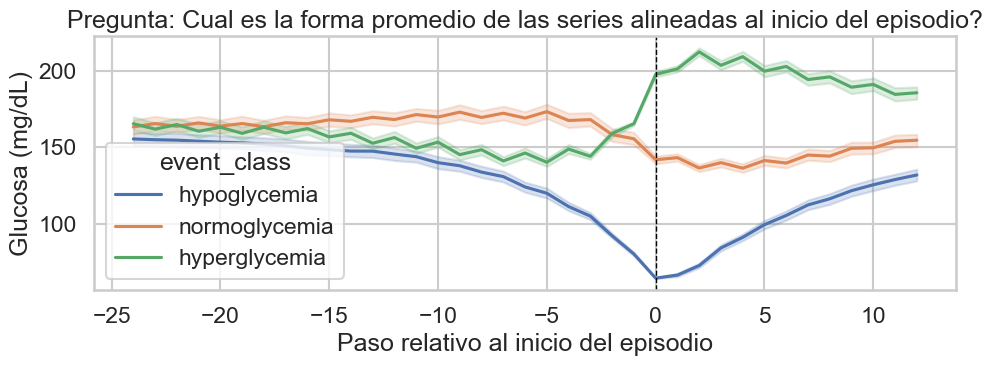

### Pregunta: Difere la varianza previa entre hipo, normo e hiper?

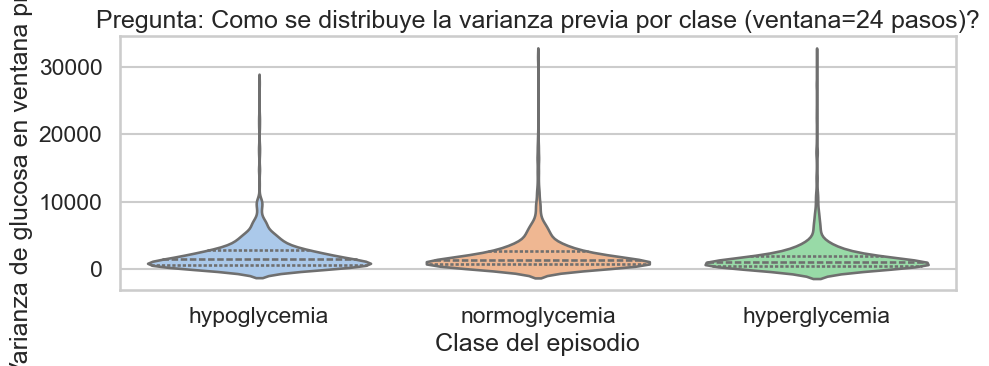

### Pregunta: Que ventana lookback captura mejor el contexto previo?

,window,effect_mean_abs_d,d_var_hypo_vs_normo,d_var_hyper_vs_normo,d_slope_hypo_vs_normo,d_slope_hyper_vs_normo
0,8,0.308558,0.078460,0.048471,0.578510,0.528791
1,12,0.258323,0.073672,0.120923,0.632113,0.206582
2,24,0.235287,0.004501,0.133185,0.620709,0.182753
3,48,0.199924,0.041688,0.140537,0.400310,0.217161


Ventana recomendada (max separabilidad media): 8 pasos


In [12]:
# Bloque 4: propiedades temporales para balanceo

# Definir inicios de episodios
analysis_glucose = analysis_glucose.sort_values(['Patient_ID', 'timestamp']).reset_index(drop=True)
analysis_glucose['row_idx'] = np.arange(len(analysis_glucose))
analysis_glucose['prev_class'] = analysis_glucose.groupby('Patient_ID')['class_label'].shift(1)
analysis_glucose['is_episode_start'] = analysis_glucose['class_label'] != analysis_glucose['prev_class']

episode_starts = analysis_glucose[
    analysis_glucose['is_episode_start'] & analysis_glucose['class_label'].isin(class_order)
].copy()

# Submuestreo para coste computacional controlado con seed fija
def sample_episode_starts(df, max_per_class=1000, seed=SEED):
    sampled = []
    for c in class_order:
        part = df[df['class_label'] == c]
        if len(part) > max_per_class:
            part = part.sample(max_per_class, random_state=seed)
        sampled.append(part)
    return pd.concat(sampled, ignore_index=True)

episode_starts_sample = sample_episode_starts(episode_starts, max_per_class=1000, seed=SEED)

# Index por paciente para extraer ventanas rapidamente
patient_to_positions = analysis_glucose.groupby('Patient_ID')['row_idx'].apply(list).to_dict()

# Mapa posicion global -> posicion local por paciente
local_pos = {}
for pid, positions in patient_to_positions.items():
    for i, p in enumerate(positions):
        local_pos[p] = (pid, i)

# Extraer trazas alineadas al inicio de episodio
pre_steps = 24
post_steps = 12
aligned_rows = []

for _, ev in episode_starts_sample.iterrows():
    global_idx = int(ev['row_idx'])
    pid, i_local = local_pos[global_idx]
    positions = patient_to_positions[pid]

    for rel in range(-pre_steps, post_steps + 1):
        j = i_local + rel
        if 0 <= j < len(positions):
            gidx = positions[j]
            aligned_rows.append({
                'event_class': ev['class_label'],
                'rel_step': rel,
                'glucose_value': analysis_glucose.loc[gidx, 'Measurement']
            })

aligned_df = pd.DataFrame(aligned_rows)

# Event-aligned average plot
display(Markdown('### Pregunta: Como evoluciona la glucosa alrededor del inicio de episodios por clase?'))
fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=aligned_df, x='rel_step', y='glucose_value', hue='event_class', hue_order=class_order, ax=ax)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Pregunta: Cual es la forma promedio de las series alineadas al inicio del episodio?')
ax.set_xlabel('Paso relativo al inicio del episodio')
ax.set_ylabel('Glucosa (mg/dL)')
plt.tight_layout()
plt.show()

# Distribucion de varianza en ventanas previas por clase
window_candidates = [8, 12, 24, 48]
feature_rows = []

for _, ev in episode_starts_sample.iterrows():
    global_idx = int(ev['row_idx'])
    pid, i_local = local_pos[global_idx]
    positions = patient_to_positions[pid]

    for w in window_candidates:
        start = i_local - w
        end = i_local
        if start >= 0:
            idxs = positions[start:end]
            vals = analysis_glucose.loc[idxs, 'Measurement'].values
            if len(vals) >= max(5, int(0.7 * w)):
                x = np.arange(len(vals))
                slope = np.polyfit(x, vals, deg=1)[0] if len(vals) > 1 else np.nan
                feature_rows.append({
                    'event_class': ev['class_label'],
                    'window': w,
                    'pre_var': np.var(vals),
                    'pre_mean': np.mean(vals),
                    'pre_slope': slope
                })

pre_features = pd.DataFrame(feature_rows)

# Visual: varianza por clase para ventana de referencia 24
ref_window = 24 if 24 in pre_features['window'].unique() else pre_features['window'].min()
ref_df = pre_features[pre_features['window'] == ref_window]

display(Markdown('### Pregunta: Difere la varianza previa entre hipo, normo e hiper?'))
fig, ax = plt.subplots(figsize=(10, 4))
sns.violinplot(data=ref_df, x='event_class', y='pre_var', order=class_order, inner='quartile', ax=ax, palette='pastel')
ax.set_title(f'Pregunta: Como se distribuye la varianza previa por clase (ventana={ref_window} pasos)?')
ax.set_xlabel('Clase del episodio')
ax.set_ylabel('Varianza de glucosa en ventana previa')
plt.tight_layout()
plt.show()

# Seleccion de ventana recomendada por separabilidad (Cohen d promedio vs normo)
def cohens_d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    va, vb = np.var(a, ddof=1), np.var(b, ddof=1)
    pooled = ((len(a)-1)*va + (len(b)-1)*vb) / (len(a)+len(b)-2)
    if pooled <= 0:
        return np.nan
    return (np.mean(a) - np.mean(b)) / np.sqrt(pooled)

window_scores = []
for w in sorted(pre_features['window'].dropna().unique()):
    part = pre_features[pre_features['window'] == w]
    normo = part[part['event_class'] == 'normoglycemia']
    hypo = part[part['event_class'] == 'hypoglycemia']
    hyper = part[part['event_class'] == 'hyperglycemia']

    d_var_hypo = abs(cohens_d(hypo['pre_var'], normo['pre_var']))
    d_var_hyper = abs(cohens_d(hyper['pre_var'], normo['pre_var']))
    d_slope_hypo = abs(cohens_d(hypo['pre_slope'], normo['pre_slope']))
    d_slope_hyper = abs(cohens_d(hyper['pre_slope'], normo['pre_slope']))

    mean_effect = np.nanmean([d_var_hypo, d_var_hyper, d_slope_hypo, d_slope_hyper])
    window_scores.append({
        'window': int(w),
        'effect_mean_abs_d': mean_effect,
        'd_var_hypo_vs_normo': d_var_hypo,
        'd_var_hyper_vs_normo': d_var_hyper,
        'd_slope_hypo_vs_normo': d_slope_hypo,
        'd_slope_hyper_vs_normo': d_slope_hyper
    })

window_scores_df = pd.DataFrame(window_scores).sort_values('effect_mean_abs_d', ascending=False)
recommended_window = int(window_scores_df.iloc[0]['window']) if not window_scores_df.empty else 24

display(Markdown('### Pregunta: Que ventana lookback captura mejor el contexto previo?'))
display(window_scores_df)
print(f'Ventana recomendada (max separabilidad media): {recommended_window} pasos')

### Ficha de auditoria de la figura: Anatomia de un Episodio (senales precursoras)

**Objetivo de la figura:**
- Mostrar que las clases clinicas divergen antes del evento (`rel_step < 0`).
- Justificar visualmente por que el modelo necesita memoria temporal y por que el balanceo debe aplicarse sobre ventanas.

**Datos exactos utilizados:**
- Entrada: `aligned_df` generado en el Bloque 4.
- Universo de eventos: inicios detectados por cambio de clase dentro de cada paciente.
- Muestreo: hasta 1000 inicios por clase (`hypoglycemia`, `normoglycemia`, `hyperglycemia`) con semilla fija (`SEED`).
- Ventana temporal de la figura: 24 pasos previos y 12 posteriores por evento.

**Construccion estadistica de la figura:**
1. Agrupacion por (`event_class`, `rel_step`).
2. Calculo de media de glucosa por punto relativo.
3. Calculo de dispersion e intervalo de confianza 95% (media +/- 1.96 * error estandar).
4. Marcado del `Paso 0` como inicio del episodio clinico.
5. Sombreado del contexto previo para enfatizar informacion predictiva pre-evento.

**Interpretacion correcta:**
- Si las curvas estan separadas en `rel_step < 0`, existe informacion discriminativa antes del cruce clinico.
- Una pendiente negativa previa en hipo y positiva en hiper respalda senales precursoras con sentido fisiologico.

**Limitaciones y controles:**
- `Paso` representa indice relativo de medicion, no tiempo fijo universal en minutos.
- El submuestreo controla coste, pero puede suavizar patrones raros de muy baja prevalencia.
- La figura es evidencia descriptiva; la validacion final requiere evaluacion fuera de muestra en el pipeline de modelado.

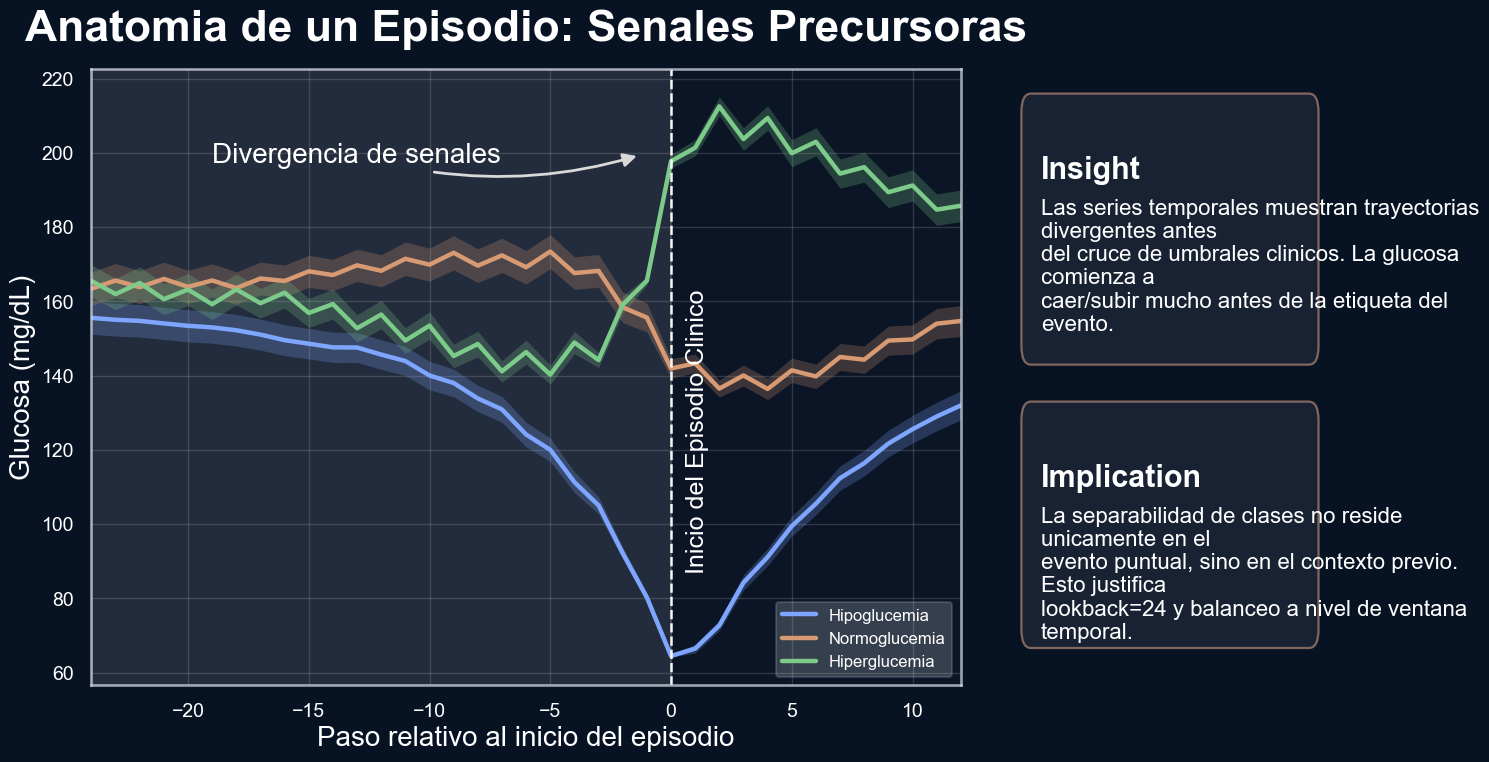

In [13]:
# Visualizacion narrativa estilo "Anatomia de un Episodio: Senales Precursoras"
import matplotlib.patches as patches

# Comprobar que existen los datos alineados del Bloque 4
required_cols = {'event_class', 'rel_step', 'glucose_value'}
if 'aligned_df' not in globals() or not required_cols.issubset(aligned_df.columns):
    raise ValueError("No existe aligned_df con las columnas necesarias. Ejecuta primero la celda principal del Bloque 4.")

plot_df = aligned_df[aligned_df['event_class'].isin(class_order)].copy()
plot_df = plot_df.dropna(subset=['rel_step', 'glucose_value'])

# Estadisticos agregados para dibujar media + IC95
agg = (
    plot_df
    .groupby(['event_class', 'rel_step'], as_index=False)['glucose_value']
    .agg(mean='mean', std='std', n='count')
)
agg['std'] = agg['std'].fillna(0.0)
agg['ci95'] = 1.96 * agg['std'] / np.sqrt(agg['n'].clip(lower=1))

# Configuracion visual
colors = {
    'hypoglycemia': '#7EA6FF',   # azul
    'normoglycemia': '#D89A73',  # marron/naranja
    'hyperglycemia': '#7DCB8A'   # verde
}
label_map = {
    'hypoglycemia': 'Hipoglucemia',
    'normoglycemia': 'Normoglucemia',
    'hyperglycemia': 'Hiperglucemia'
}

xmin = int(agg['rel_step'].min())
xmax = int(agg['rel_step'].max())

fig = plt.figure(figsize=(16, 8), facecolor='#071223')
gs = fig.add_gridspec(1, 2, width_ratios=[3.5, 1.3], wspace=0.08)
ax = fig.add_subplot(gs[0, 0])
ax_info = fig.add_subplot(gs[0, 1])

ax.set_facecolor('#0B1526')
ax_info.set_facecolor('#0B1526')
ax_info.axis('off')

# Sombreado del contexto previo al evento
ax.axvspan(xmin, 0, color='white', alpha=0.10, zorder=0)

# Curvas por clase: media + intervalo de confianza
for c in class_order:
    part = agg[agg['event_class'] == c].sort_values('rel_step')
    if part.empty:
        continue

    x = part['rel_step'].values
    y = part['mean'].values
    y_low = (part['mean'] - part['ci95']).values
    y_high = (part['mean'] + part['ci95']).values

    ax.fill_between(x, y_low, y_high, color=colors[c], alpha=0.24, linewidth=0)
    ax.plot(x, y, color=colors[c], linewidth=3.2, label=label_map[c])

# Linea de inicio de episodio
ax.axvline(0, color='white', linestyle='--', linewidth=1.8, alpha=0.95)
ax.text(
    0.6,
    ax.get_ylim()[0] + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.18,
    'Inicio del Episodio Clinico',
    color='white',
    fontsize=18,
    rotation=90,
    va='bottom',
    ha='left'
 )

# Flecha y etiqueta de divergencia en la zona previa
y_mid = ax.get_ylim()[0] + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.86
ax.annotate(
    'Divergencia de senales',
    xy=(-1.3, y_mid),
    xytext=(-19, y_mid),
    color='white',
    fontsize=20,
    arrowprops=dict(
        arrowstyle='-|>',
        color='#D9D9D9',
        lw=2,
        connectionstyle='arc3,rad=0.15'
    ),
    ha='left',
    va='center'
 )

# Estilo de ejes
ax.set_xlim(xmin, xmax)
ax.set_title('Anatomia de un Episodio: Senales Precursoras', color='white', fontsize=32, pad=20, fontweight='bold')
ax.set_xlabel('Paso relativo al inicio del episodio', color='white', fontsize=20)
ax.set_ylabel('Glucosa (mg/dL)', color='white', fontsize=20)
ax.tick_params(colors='white', labelsize=14)
for spine in ax.spines.values():
    spine.set_color('#D0D6E0')
    spine.set_alpha(0.75)
ax.grid(True, color='white', alpha=0.15, linestyle='-', linewidth=1.0)

leg = ax.legend(loc='lower right', frameon=True, fontsize=12)
leg.get_frame().set_alpha(0.18)
leg.get_frame().set_edgecolor('#D0D6E0')
for text in leg.get_texts():
    text.set_color('white')

# Panel derecho con lectura ejecutiva
def add_text_box(ax_box, x, y, w, h, title, text):
    rect = patches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle='round,pad=0.02,rounding_size=0.03',
        linewidth=1.6,
        edgecolor='#8D6E63',
        facecolor='#1A2434',
        alpha=0.92,
        transform=ax_box.transAxes
    )
    ax_box.add_patch(rect)
    ax_box.text(x + 0.04, y + h - 0.08, title, transform=ax_box.transAxes,
                fontsize=22, color='white', fontweight='bold', va='top', ha='left')
    ax_box.text(x + 0.04, y + h - 0.15, text, transform=ax_box.transAxes,
                fontsize=16, color='white', va='top', ha='left', wrap=True)

insight_text = (
    'Las series temporales muestran trayectorias divergentes antes\n'
    'del cruce de umbrales clinicos. La glucosa comienza a\n'
    'caer/subir mucho antes de la etiqueta del evento.'
)

implication_text = (
    'La separabilidad de clases no reside unicamente en el\n'
    'evento puntual, sino en el contexto previo. Esto justifica\n'
    'lookback=24 y balanceo a nivel de ventana temporal.'
)

add_text_box(ax_info, 0.06, 0.54, 0.88, 0.40, 'Insight', insight_text)
add_text_box(ax_info, 0.06, 0.08, 0.88, 0.36, 'Implication', implication_text)

plt.show()

### Como se construye esta visualizacion (auditoria tecnica)

Para construir esta visualizacion, el analisis sigue estos pasos tecnicos:

- **Muestreo masivo por clase:** se identifican todos los inicios de episodios (momentos donde cambia la clase clinica) y se realiza un submuestreo de hasta 1000 inicios por cada clase (`hypoglycemia`, `normoglycemia`, `hyperglycemia`) usando una semilla fija, para que el conjunto sea representativo y reproducible.

- **Alineacion temporal:** para cada evento (hasta 3000 en total), se extrae una ventana de datos que abarca 24 pasos hacia atras (pasado) y 12 pasos hacia adelante (futuro), tomando como referencia el momento exacto en que comienza el episodio (`rel_step = 0`).

- **Calculo del promedio (linea central):** cada linea solida representa la media de glucosa de todos esos fragmentos alineados por clase. No corresponde a un individuo concreto, sino al patron tipico de la dinamica glucemica de la clase.

- **Intervalo de confianza (area sombreada):** el sombreado alrededor de cada linea resume la variabilidad de los eventos (a partir del error estandar e IC95), y permite evaluar que las trayectorias ya se separan antes de que el episodio ocurra.

In [14]:
# Implicacion para experimentos - Bloque 4
imp_b4 = f"""
**Implicacion para los experimentos:**
Las señales previas al episodio muestran separabilidad entre clases en varianza y pendiente, y la mejor longitud de lookback observada fue **{recommended_window}** pasos.
Se recomienda construir datasets de entrenamiento basados en ventanas con ese contexto previo e incluir estrategias de augmentacion que preserven dinamica temporal (no solo redistribucion de muestras puntuales).
"""
display(Markdown(imp_b4))


**Implicacion para los experimentos:**
Las señales previas al episodio muestran separabilidad entre clases en varianza y pendiente, y la mejor longitud de lookback observada fue **8** pasos.
Se recomienda construir datasets de entrenamiento basados en ventanas con ese contexto previo e incluir estrategias de augmentacion que preserven dinamica temporal (no solo redistribucion de muestras puntuales).


## Bloque 5 - Sintesis para el diseño experimental

In [15]:
# Sintesis final estructurada

# Ratios observados para simulacion
ratios_finite = patient_class_counts['imbalance_ratio_max'].replace([np.inf, -np.inf], np.nan).dropna()
q50 = ratios_finite.quantile(0.50) if len(ratios_finite) else np.nan
q75 = ratios_finite.quantile(0.75) if len(ratios_finite) else np.nan
q90 = ratios_finite.quantile(0.90) if len(ratios_finite) else np.nan

# Tecnicas candidatas justificadas por hallazgos
techniques = []
if mean_minor_ac.get('hypoglycemia', 0) > 0.05 or mean_minor_ac.get('hyperglycemia', 0) > 0.05:
    techniques.append('SMOTE temporal / TimeSeries-aware oversampling (hay dependencia temporal y rafagas).')
techniques.append('Balanceo a nivel ventana (window-level) en lugar de muestra puntual (coherente con episodios consecutivos).')
if top5_hypo_share > 40 or top5_hyper_share > 40:
    techniques.append('Estrategia patient-aware (grouped resampling) para evitar sobreajuste a pocos pacientes dominantes.')

# Estratificacion recomendada
strat_vars = predictor_scores_df.dropna(subset=['predictive_score'])['variable'].head(2).tolist() if not predictor_scores_df.empty else []
if len(strat_vars) == 0:
    strat_text = 'Estratificar al menos por severidad de desbalanceo del paciente y por Patient_ID (Group split).'
else:
    strat_text = 'Estratificar train/test por: ' + ', '.join(strat_vars) + ', manteniendo Group split por Patient_ID.'

# Riesgos identificados
patients_without_hypo = int((patient_class_counts['hypoglycemia'] == 0).sum())
patients_without_hyper = int((patient_class_counts['hyperglycemia'] == 0).sum())

insight_md = f"""
## Insights para el diseño experimental

### Ratios de desbalanceo a simular
- Mediana de ratio maximo observado: **{q50:.2f}:1**
- Percentil 75: **{q75:.2f}:1**
- Percentil 90: **{q90:.2f}:1**
- Incluir escenarios extremos con ausencia de una minoritaria en ciertos pacientes.

### Tecnicas candidatas (justificadas por los datos)
- {'\n- '.join(techniques)}

### Estratificacion recomendada
- {strat_text}

### Metricas de evaluacion prioritarias (regresion)
- MAE y RMSE globales para error absoluto y penalizacion de errores grandes.
- Error por rangos clinicos de glucosa (hipo/normo/hiper) para comprobar sesgo en zonas minoritarias.
- MAE/RMSE por paciente y por subgrupo (no solo promedio global).
- Error en horizontes temporales de interes (p. ej., a 15, 30, 60 min si aplica).
- Metricas de deteccion derivadas del valor predicho solo como evaluacion secundaria (p. ej., recall de hipoglucemia tras umbralizar la prediccion).

### Nota metodologica clave
- Aunque la tarea final sea de **prediccion continua (regresion)**, el desbalanceo sigue siendo critico: sin correccion, el modelo tiende a optimizar la zona mayoritaria y a degradar la precision en eventos extremos clinicamente relevantes.
- Por ello se recomienda combinar balanceo temporal con entrenamiento ponderado por regiones clinicas/extremos y validacion estratificada.

### Riesgos identificados
- Pacientes sin hipoglucemia: **{patients_without_hypo}**.
- Pacientes sin hiperglucemia: **{patients_without_hyper}**.
- Concentracion de eventos en pocos pacientes (top 5 hipo={top5_hypo_share:.1f}%, top 5 hiper={top5_hyper_share:.1f}%).
- Riesgo de leakage temporal si no se respeta orden cronologico en split y balanceo.
"""

display(Markdown(insight_md))


## Insights para el diseño experimental

### Ratios de desbalanceo a simular
- Mediana de ratio maximo observado: **17.79:1**
- Percentil 75: **37.62:1**
- Percentil 90: **97.51:1**
- Incluir escenarios extremos con ausencia de una minoritaria en ciertos pacientes.

### Tecnicas candidatas (justificadas por los datos)
- SMOTE temporal / TimeSeries-aware oversampling (hay dependencia temporal y rafagas).
- Balanceo a nivel ventana (window-level) en lugar de muestra puntual (coherente con episodios consecutivos).

### Estratificacion recomendada
- Estratificar train/test por: Age, age_group, manteniendo Group split por Patient_ID.

### Metricas de evaluacion prioritarias (regresion)
- MAE y RMSE globales para error absoluto y penalizacion de errores grandes.
- Error por rangos clinicos de glucosa (hipo/normo/hiper) para comprobar sesgo en zonas minoritarias.
- MAE/RMSE por paciente y por subgrupo (no solo promedio global).
- Error en horizontes temporales de interes (p. ej., a 15, 30, 60 min si aplica).
- Metricas de deteccion derivadas del valor predicho solo como evaluacion secundaria (p. ej., recall de hipoglucemia tras umbralizar la prediccion).

### Nota metodologica clave
- Aunque la tarea final sea de **prediccion continua (regresion)**, el desbalanceo sigue siendo critico: sin correccion, el modelo tiende a optimizar la zona mayoritaria y a degradar la precision en eventos extremos clinicamente relevantes.
- Por ello se recomienda combinar balanceo temporal con entrenamiento ponderado por regiones clinicas/extremos y validacion estratificada.

### Riesgos identificados
- Pacientes sin hipoglucemia: **2**.
- Pacientes sin hiperglucemia: **1**.
- Concentracion de eventos en pocos pacientes (top 5 hipo=6.8%, top 5 hiper=4.0%).
- Riesgo de leakage temporal si no se respeta orden cronologico en split y balanceo.
